# 파머완 4.9 분류 실습 - 캐글 산탄데르 고객 만족 예측

## 데이터 전처리

In [1]:
#1 데이터 로드

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import warnings

warnings.filterwarnings('ignore')
cust_df=pd.read_csv("train_santander.csv",encoding='latin-1')
print('dataset shape:',cust_df.shape)
cust_df.head(3)

dataset shape: (76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.17,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.77,0


In [3]:
#2 데이터 확인 및 전처리

In [4]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [5]:
print(cust_df['TARGET'].value_counts())
unsatisfied_cnt=cust_df[cust_df['TARGET']==1].TARGET.count()
total_cnt=cust_df.TARGET.count()
print('unsatisfied 비율은 {0:.2f}'.format((unsatisfied_cnt/total_cnt)))

TARGET
0    73012
1     3008
Name: count, dtype: int64
unsatisfied 비율은 0.04


-> unsatisfied는 4%로 매우 불균형한 데이터임
- value_counts()는 각 고유값이 몇 번 등장하는지 빈도를 셈
- count()는 NaN이 아닌 값의 개수를 셈

In [6]:
cust_df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


-> var3의 min 값이 -999999로 편차가 너무 심함  
-> 아마 NaN이나 특정 예외값을 변환한 것  

In [7]:
print(cust_df.var3.value_counts()[:10])

var3
 2         74165
 8           138
-999999      116
 9           110
 3           108
 1           105
 13           98
 7            97
 4            86
 12           85
Name: count, dtype: int64


-> 조사해보니 -999999이 116개나 있음  
  
-> -999999을 가장 많은 2로 변환  
-> ID는 단순 식별자이므로 드롭

In [8]:
#3 데이터 분리하고 소수의 레이블 1값이 학습 테스트 데이터 세트에 잘 나뉘어 들어갔는지 확인

학습 테스트 데이터 분리

In [9]:
cust_df['var3'].replace(-999999,2,inplace=True)
cust_df.drop('ID',axis=1,inplace=True)

# 피처 세트와 레이블 세트 분리. 레이블 칼럼은 DataFrame의 맨 마지막에 위치해 칼럼 위치 -1로 분리
X_features=cust_df.iloc[:,:-1]
y_labels=cust_df.iloc[:,-1]
print('피처 데이터 shape:{0}'.format(X_features.shape))

피처 데이터 shape:(76020, 369)


In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X_features,y_labels,test_size=0.2, random_state=0)

train_cnt=y_train.count()
test_cnt=y_test.count()
print('학습 세트 Shape:{0}, 테스트 세트 Shape:{1}'.format(X_train.shape,X_test.shape))

print('학습 세트 레이블 값 분포 비율')
print(y_train.value_counts()/train_cnt)

print('테스트 세트 레이블 값 분포 비율')
print(y_test.value_counts()/train_cnt)

학습 세트 Shape:(60816, 369), 테스트 세트 Shape:(15204, 369)
학습 세트 레이블 값 분포 비율
TARGET
0    0.960964
1    0.039036
Name: count, dtype: float64
테스트 세트 레이블 값 분포 비율
TARGET
0    0.239575
1    0.010425
Name: count, dtype: float64


-> value_counts()에 수식 적용 가능함

학습 검증 데이터 분리  
<-XGB의 조기 중단을 위해

In [11]:
X_tr,X_val,y_tr,y_val=train_test_split(X_train,y_train,test_size=0.3,random_state=0)

## XGBoost 모델 학습과 하이퍼 파라미터 튜닝

In [12]:
#1 XGBoost의 모델 학습(조기 중단 사용)

- early_stopping_rounds랑 eval_metric 인자 XGBClassifier 생성자 안에 넣기

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# n_estimators는 500으로, random state는 예제 수행시마다 동일 예측 결과를 위해 설정
xgb_clf=XGBClassifier(n_estimators=500, learning_rate=0.05, early_stopping_rounds=100, eval_metric="auc",random_state=156)

# 성능 평가 지표를 auc로, 조기 중단 파라미터는 100으로 설정하고 학습 수행
xgb_clf.fit(X_tr,y_tr, eval_set=[(X_tr,y_tr),(X_val,y_val)])

xgb_roc_score=roc_auc_score(y_test,xgb_clf.predict_proba(X_test)[:,1])
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.83603	validation_1-auc:0.80978
[1]	validation_0-auc:0.83783	validation_1-auc:0.81126
[2]	validation_0-auc:0.83892	validation_1-auc:0.81192
[3]	validation_0-auc:0.84090	validation_1-auc:0.81349
[4]	validation_0-auc:0.84187	validation_1-auc:0.81356
[5]	validation_0-auc:0.84355	validation_1-auc:0.81422
[6]	validation_0-auc:0.84534	validation_1-auc:0.81550
[7]	validation_0-auc:0.84658	validation_1-auc:0.81623
[8]	validation_0-auc:0.84727	validation_1-auc:0.81669
[9]	validation_0-auc:0.84794	validation_1-auc:0.81668
[10]	validation_0-auc:0.84980	validation_1-auc:0.81828
[11]	validation_0-auc:0.85105	validation_1-auc:0.81965
[12]	validation_0-auc:0.85217	validation_1-auc:0.81999
[13]	validation_0-auc:0.85301	validation_1-auc:0.82049
[14]	validation_0-auc:0.85558	validation_1-auc:0.82210
[15]	validation_0-auc:0.85662	validation_1-auc:0.82288
[16]	validation_0-auc:0.85811	validation_1-auc:0.82380
[17]	validation_0-auc:0.85864	validation_1-auc:0.82365
[18]	validation_0-au

In [14]:
#2 HyperOpt을 이용해 베이지안 최적화 기반으로 하이퍼 파라미터 튜닝

1. 검색 공간 설정

In [15]:
from hyperopt import hp

# max_depth는 5~15 사이 정수값(1 간격), min_child_weight는 1~6 사이 정수값(1 간격) 중 균등하게 샘플링
# colsample_bytree는 0.5~0.95, learning_rate는 0.01~0.2 사이 연속 실수값을 균등하게 샘플링
# (HyperOpt가 좋은 결과 근처를 정규분포 모양으로 집중 탐색하며 최적값을 찾아감)
xgb_search_space={'max_depth':hp.quniform('max_depth',5,15,1),
                   'min_child_weight':hp.quniform('min_child_weight',5,6,1),
                   'colsample_bytree':hp.uniform('colsample_bytree',0.5,0.95),
                   'learning_rate':hp.uniform('learning_rate',0.01,0.2)}

2. 목적 함수 설정

In [16]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

# fmin()에서 호출 시 search_space 값으로 XGBClassifier교차 검증 학습 수 -1*roc_auc 평균 값을 반환
def objective_func(search_space):
    xgb_clf = XGBClassifier(n_estimators=500, 
                            max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            colsample_bytree=search_space['colsample_bytree'],
                            learning_rate=search_space['learning_rate'],
                            early_stopping_rounds=30,eval_metric="auc")
    # 3개 k-fold 방식으로 평가된 roc_auc 지표를 담는 list
    roc_auc_list=[]

    # 3개 k-fold 방식 적용
    kf=KFold(n_splits=3)
    # X_train을 다시 학습과 검증용 데이터로 분리
    for tr_index,val_index in kf.split(X_train):
        # kf.split(X_train)으로 추출된 학습과 검증 index 값으로 학습과 검증 데이터 세트 분리
        X_tr,y_tr=X_train.iloc[tr_index],y_train.iloc[tr_index]
        X_val,y_val=X_train.iloc[val_index],y_train.iloc[val_index]

        # early stopping은 30회로 설정하고 추출된 학습과 검증 데이터로 XGBClassifier 학습 수행
        xgb_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)])

        # 1로 예측한 확률값 추출 후 roc auc 계산하고 평균 roc auc 계산을 위해 list에 결괏값 담음
        score=roc_auc_score(y_val,xgb_clf.predict_proba(X_val)[:,1])
        roc_auc_list.append(score)

    # 3개 k_fold로 계산된 roc_auc 값의 평균값을 반환하되,
    # HyperOpt는 목적함수의 최솟값을 위한 입력값을 찾으므로 -1을 곱한 뒤 반환
    return -1*np.mean(roc_auc_list)

**목적**: 어떤 파라미터 세트로 학습해야 auc가 높게 나오는가?  
**주의**: 파라미터 세트가 같더라도 각각의 kfold를 수행하면서 달라지는 학습 세트에 따라 xgb의 결정트리 모양과 가중치는 달라짐 -> 파라미터와 결정트리 모양 및 가중치 혼동하지 않기  

**전체 흐름**  
베이지안 (fmin)  
→ 파라미터 세트 제안  
   예: max_depth=7, learning_rate=0.05  

    → KFold 3번 반복 (신뢰있는 AUC 측정을 위해)
       
        → XGB 학습 (3번 모두 베이지안이 제안한 같은 파라미터로 다른 학습 데이터를 통해 트리 쌓으며 학습)
          → AUC 측정

    → 3번 AUC 평균 → 베이지안에 반환

→ 베이지안: "이 파라미터는 0.85였네, 다음엔 이쪽을 탐색하자"  
→ 다음 파라미터 세트 제안  
→ 반복... 

**+) xgb의 흐름**  
n_estimators만큼 결정 트리를 하나 씩 추가해가며 학습함  
-> 이때 추가한 결정 트리는 앞의 결정 트리의 오차를 학습함  
ex) 앞의 결정트리 예측값: 400, 실제값: 500 -> 뒤의 결정트리는 500-400=100인 **앞의 결정트리들의 오차를 학습**

3. 목적 함수의 반환 최솟값을 가지는 최적 입력값 유추 - fmin() 이용

In [23]:
from hyperopt import fmin,tpe, Trials

trials=Trials()

#fmin() 함수를 호출 -> max_evals 지정된 횟수만큼 반복 후 목적함수의 최솟값을 가지는 최적 입력값 추출
best=fmin(fn=objective_func,
          space=xgb_search_space,
          algo=tpe.suggest, # 베이지안 최적화 적용 알고리즘: 좋은 결과가 나온 파라미터 근처 탐색해서 제안
          max_evals=50, # 최대 반복 횟수 지정
          trials=trials,rstate=np.random.default_rng(seed=30)) # Trial 객체에 탐색 기록 저장

print('best:',best) # 최적의 파라미터 조합 반환

[0]	validation_0-auc:0.77079	validation_1-auc:0.73421                                                                  
[1]	validation_0-auc:0.77995	validation_1-auc:0.74083                                                                  
[2]	validation_0-auc:0.78260	validation_1-auc:0.74441                                                                  
[3]	validation_0-auc:0.82647	validation_1-auc:0.79478                                                                  
[4]	validation_0-auc:0.82428	validation_1-auc:0.79199                                                                  
[5]	validation_0-auc:0.83645	validation_1-auc:0.80470                                                                  
[6]	validation_0-auc:0.84181	validation_1-auc:0.80923                                                                  
[7]	validation_0-auc:0.84635	validation_1-auc:0.81622                                                                  
[8]	validation_0-auc:0.84537	validation_

In [24]:
#3 최적으로 찾은 하이퍼 파라미터를 기반으로 학습과 예측 수행

In [25]:
# n_estimators를 500 증가
xgb_clf=XGBClassifier(n_estimators=500, learning_rate=round(best['learning_rate'],5),
                      max_depth=int(best['max_depth']),
                      min_child_weight=int(best['min_child_weight']),
                      colsample_bytree=round(best['colsample_bytree'],5),
                      early_stopping_rounds=100,
                      eval_metric="auc"
                     )

# evaluation metric을 auc로, early stopping은 100으로 설정하고 학습 수행. 
xgb_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)])

xgb_roc_score=roc_auc_score(y_test,xgb_clf.predict_proba(X_test)[:,1]) # roc_auc는 임곗값을 0에서 1까지 올려가며 그래프를 그려야하기 때문에 확률값이 필요
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.75616	validation_1-auc:0.72423
[1]	validation_0-auc:0.76645	validation_1-auc:0.73605
[2]	validation_0-auc:0.77463	validation_1-auc:0.74490
[3]	validation_0-auc:0.82038	validation_1-auc:0.79940
[4]	validation_0-auc:0.82068	validation_1-auc:0.79652
[5]	validation_0-auc:0.83227	validation_1-auc:0.81047
[6]	validation_0-auc:0.84064	validation_1-auc:0.82017
[7]	validation_0-auc:0.84533	validation_1-auc:0.82462
[8]	validation_0-auc:0.84656	validation_1-auc:0.82236
[9]	validation_0-auc:0.85080	validation_1-auc:0.82641
[10]	validation_0-auc:0.85167	validation_1-auc:0.82590
[11]	validation_0-auc:0.85598	validation_1-auc:0.82860
[12]	validation_0-auc:0.85506	validation_1-auc:0.82761
[13]	validation_0-auc:0.85465	validation_1-auc:0.82672
[14]	validation_0-auc:0.85834	validation_1-auc:0.82916
[15]	validation_0-auc:0.85923	validation_1-auc:0.82915
[16]	validation_0-auc:0.86120	validation_1-auc:0.83167
[17]	validation_0-auc:0.86153	validation_1-auc:0.83082
[18]	validation_0-au

In [26]:
#4 튜닝된 모델에서 각 피처의 중요도 확인

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

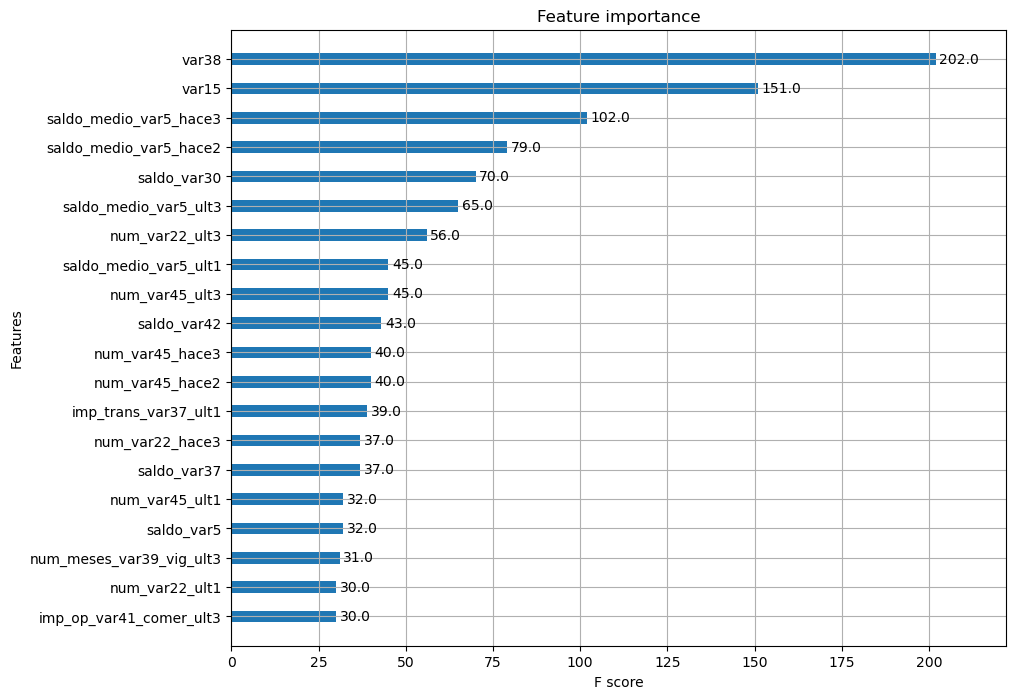

In [27]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig,ax=plt.subplots(1,1,figsize=(10,8))
plot_importance(xgb_clf,ax=ax,max_num_features=20,height=0.4)

### LightGBM 모델 학습과 하이퍼 파라미터 튜닝

In [45]:
from lightgbm import LGBMClassifier

lgbm_clf=LGBMClassifier(n_estimators=500, early_stopping_rounds=100)

eval_set=[(X_tr,y_tr),(X_val,y_val)]
lgbm_clf.fit(X_tr,y_tr,eval_set=eval_set, eval_metric="auc")

lgbm_roc_score=roc_auc_score(y_test,lgbm_clf.predict_proba(X_test)[:,1])
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[1]	training's auc: 0.82625	training's binary_logloss: 0.15523	valid_1's auc: 0.809814	valid_1's binary_logloss: 0.15774
[2]	training's auc: 0.833899	training's binary_logloss: 0.149581	valid_1's auc: 0.81222	valid_1's binary_logloss: 0.153275
[3]	training's auc: 0.841789	training's binary_logloss: 0.145416	valid_1's auc: 0.814833	valid_1's binary_logloss: 0.149999
[4]	training's auc: 0.847243	training's binary_logloss: 0.14212	valid_1's auc: 0.819406	valid_1's binary_logloss: 0.147524
[5]	training's auc: 0.849589	training's binary_logloss: 0.139438	valid_1's auc: 0.821869	valid_1's binary_logloss: 0.145464
[6]	training's auc: 0.853413	training's binary_logloss: 0.137254	valid_1's auc: 0.820878	valid_1's binary_logloss: 0.143973
[7]	training's auc: 0.85551	training's binary_logloss: 0.1354	valid_1's auc: 0.821815	valid_1's binary_logloss: 0.142746
[8]

In [46]:
lgbm_search_space={'num_leaves':hp.quniform('num_leaves',32,64,1),
                   'max_depth':hp.quniform('max_depth',100,160,1),
                   'min_child_samples':hp.quniform('min_child_samples',60,100,1),
                   'subsample':hp.uniform('subsample',0.7,1),
                   'learning_rate':hp.uniform('learning_rate',0.01,0.2)}

In [51]:
def objective_func(search_space):
    lgbm_clf = LGBMClassifier(n_estimators=500, 
                              num_leaves=int(search_space['num_leaves']),
                              max_depth=int(search_space['max_depth']),
                              min_child_samples=int(search_space['min_child_samples']),
                              subsample=search_space['subsample'],
                              learning_rate=search_space['learning_rate'],
                              early_stopping_round=30)
    
    # 3개 k-fold 방식으로 평가된 roc_auc 지표를 담는 list
    roc_auc_list=[]

    # 3개 k-fold 방식 적용
    kf=KFold(n_splits=3)
    # X_train을 다시 학습과 검증용 데이터로 분리
    for tr_index,val_index in kf.split(X_train):
        # kf.split(X_train)으로 추출된 학습과 검증 index 값으로 학습과 검증 데이터 세트 분리
        X_tr,y_tr=X_train.iloc[tr_index],y_train.iloc[tr_index]
        X_val,y_val=X_train.iloc[val_index],y_train.iloc[val_index]

        # early stopping은 30회로 설정하고 추출된 학습과 검증 데이터로 LGBMClassifier 학습 수행
        lgbm_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)],eval_metric="auc")

        # 1로 예측한 확률값 추출 후 roc auc 계산하고 평균 roc auc 계산을 위해 list에 결괏값 담음
        score=roc_auc_score(y_val,lgbm_clf.predict_proba(X_val)[:,1])
        roc_auc_list.append(score)

    # 3개 k_fold로 계산된 roc_auc 값의 평균값을 반환하되,
    # HyperOpt는 목적함수의 최솟값을 위한 입력값을 찾으므로 -1을 곱한 뒤 반환
    return -1*np.mean(roc_auc_list)

In [53]:
from hyperopt import fmin,tpe, Trials

trials=Trials()

#fmin() 함수를 호출 -> max_evals 지정된 횟수만큼 반복 후 목적함수의 최솟값을 가지는 최적 입력값 추출
best=fmin(fn=objective_func,
          space=lgbm_search_space,
          algo=tpe.suggest, # 베이지안 최적화 적용 알고리즘: 좋은 결과가 나온 파라미터 근처 탐색해서 제안
          max_evals=50, # 최대 반복 횟수 지정
          trials=trials,rstate=np.random.default_rng(seed=30)) # Trial 객체에 탐색 기록 저장

print('best:',best)

[1]	training's auc: 0.82736	training's binary_logloss: 0.162294	valid_1's auc: 0.804818	valid_1's binary_logloss: 0.163544
[2]	training's auc: 0.828309	training's binary_logloss: 0.160269	valid_1's auc: 0.804585	valid_1's binary_logloss: 0.161866
[3]	training's auc: 0.833368	training's binary_logloss: 0.158478	valid_1's auc: 0.806871	valid_1's binary_logloss: 0.16038
[4]	training's auc: 0.834671	training's binary_logloss: 0.156852	valid_1's auc: 0.80706	valid_1's binary_logloss: 0.159053
[5]	training's auc: 0.837783	training's binary_logloss: 0.155354	valid_1's auc: 0.811645	valid_1's binary_logloss: 0.157793
[6]	training's auc: 0.839052	training's binary_logloss: 0.153966	valid_1's auc: 0.81271	valid_1's binary_logloss: 0.156635
[7]	training's auc: 0.841216	training's binary_logloss: 0.152691	valid_1's auc: 0.815103	valid_1's binary_logloss: 0.155585
[8]	training's auc: 0.841859	training's binary_logloss: 0.151499	valid_1's auc: 0.814773	valid_1's binary_logloss: 0.154617
[9]	training

In [55]:
lgbm_clf=LGBMClassifier(n_estimators=500, num_leaves=int(best['num_leaves']),
                        max_depth=int(best['max_depth']),
                        min_child_samples=int(best['min_child_samples']),
                        subsample=round(best['subsample'],5),
                        learning_rate=round(best['learning_rate'],5),
                        early_stopping_round=100, 
                        eval_metric="auc")

# evaluation metric을 auc로, early stopping은 100으로 설정하고 학습 수행. 
lgbm_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)])

lgbm_roc_score=roc_auc_score(y_test,lgbm_clf.predict_proba(X_test)[:,1]) # roc_auc는 임곗값을 0에서 1까지 올려가며 그래프를 그려야하기 때문에 확률값이 필요
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Warning] Unknown parameter: eval_metric
[1]	training's binary_logloss: 0.163279	valid_1's binary_logloss: 0.164382
[2]	training's binary_logloss: 0.162061	valid_1's binary_logloss: 0.163347
[3]	training's binary_logloss: 0.160933	valid_1's binary_logloss: 0.162375
[4]	training's binary_logloss: 0.159878	valid_1's binary_logloss: 0.161424
[5]	training's binary_logloss: 0.158879	valid_1's binary_logloss: 0.160554
[6]	training's binary_logloss: 0.157946	valid_1's binary_logloss: 0.159721
[7]	training's binary_logloss: 0.157045	valid_1's binary_logloss: 0.15897
[8]	training's binary_logloss: 0.15618	valid_1's binary_logloss: 0.158234
[9]	training's binary_logloss: 0.155362	valid_1's binary_logloss: 0.157534
[10]	training's binary_logloss: 0.15457	valid_1's binary_logloss: 0.156886
[11]	training's binary_logloss: 0.153818	valid_1's binary_logloss: 0.156283
[12]	training's binary_logloss: 0.153095	valid_1's binary_logloss: 0.15565
[13]	training's binary_logloss: 0.152394	valid_1'